In [1]:
import numpy as np
from scipy import signal as sg
import soundfile as sf
import matplotlib
from matplotlib import pyplot as plt

In [2]:
song_stereo = (sf.read(file="untitled_excerpt.wav")[0])
song = (song_stereo[:, 0] + song_stereo[:, 1]) / 2
print(song)

BITRATE = 48000
print(len(song))

segment = song[:222222]

[ 0.00000000e+00  1.06811523e-04  1.98364258e-04 ... -1.52587891e-05
  1.52587891e-05 -1.52587891e-05]
948000


Saved waveform.png


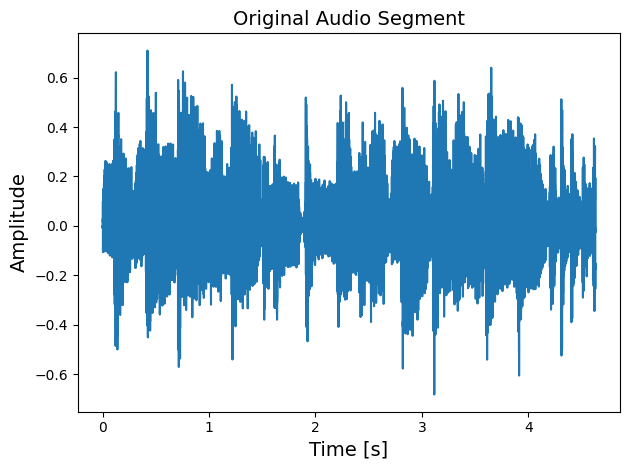

In [3]:
# Song visualization

figure = plt.figure()
ax = figure.add_subplot(1, 1, 1)
ax.set_title(r'Original Audio Segment', fontsize=14)

ax.set_xlabel(r'Time [s]', fontsize=14)

ax.set_ylabel('Amplitude', fontsize=14)

ax.plot(np.linspace(0, len(segment) / BITRATE, len(segment)), segment)

plt.tight_layout()
plt.savefig('waveform.png', dpi=150, bbox_inches='tight')
print("Saved waveform.png")

Saved psd.png


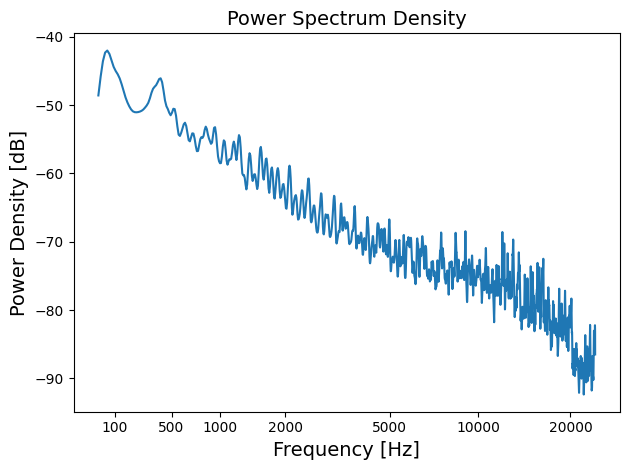

In [4]:
# Get power via welch's method
power_freqs, power_vals = sg.welch(song, fs=BITRATE, nperseg=2048, noverlap=1024, nfft=4096, window="blackmanharris")
power_vals_db = 10 * np.log10(power_vals)

# Perceptual frequency axis transformation (more convenient than pure log scale for audio analysis)
def hz_to_mel(f):
    return 2595 * np.log10(1 + f / 700)

mel_freqs = hz_to_mel(power_freqs[1:BITRATE // 2])

# Power visualization
figure = plt.figure()
ax = figure.add_subplot(1, 1, 1)
ax.set_title(r'Power Spectrum Density', fontsize=14)

ax.set_xlabel(r'Frequency [Hz]', fontsize=14)

# Manually set ticks at meaningful Hz values, converted to mel
tick_hz = [100, 500, 1000, 2000, 5000, 10000, 20000]
ax.set_xticks([hz_to_mel(f) for f in tick_hz])
ax.set_xticklabels([str(f) for f in tick_hz])

ax.set_ylabel(r'Power Density [dB]', fontsize=14)

ax.plot(mel_freqs, power_vals_db[1:])

plt.tight_layout()
plt.savefig('psd.png', dpi=150, bbox_inches='tight')
print("Saved psd.png")

In [77]:
fL = 390
fH = 3030

ws=[350, 3500]

gpass = 0.05
gstop = 40


print("in rads:", fL * 2 * np.pi / BITRATE, fH * 2 * np.pi / BITRATE)

bp_ord, wn = sg.cheb2ord(wp=[fL, fH], ws=ws, gpass=gpass, gstop=gstop, fs=BITRATE, analog=False)
bp_sos = sg.cheby2(N=bp_ord, rs=gstop, Wn=wn, btype='bandpass', output='sos', fs=BITRATE, analog=False)
bp_z, bp_p, bp_k = sg.cheby2(N=bp_ord, rs=gstop, Wn=wn, btype='bandpass', output='zpk', fs=BITRATE, analog=False)
bp_b, bp_a = sg.sos2tf(bp_sos)

print(bp_ord)

in rads: 0.051050880620834134 0.3966260725157114
15


Saved pole_zero.png


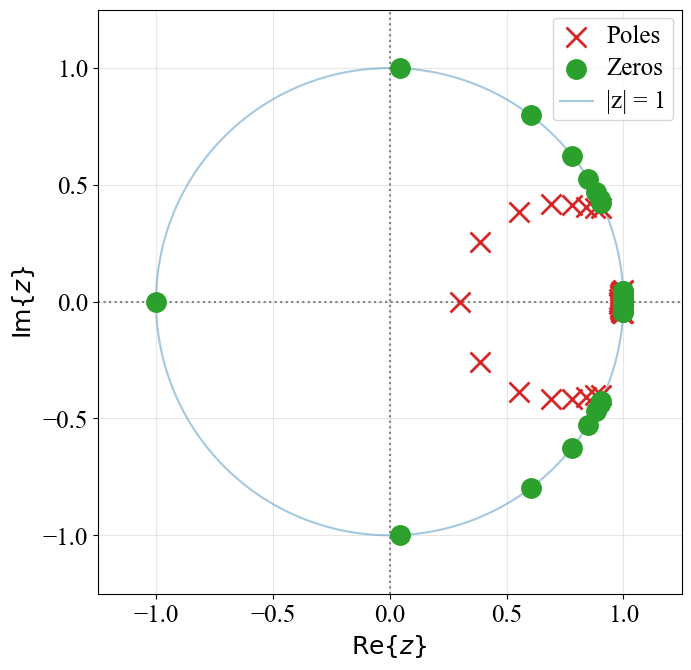

In [6]:
# Pole-Zero plot
GOLDEN_RATIO = (1 + 5**0.5) / 2
FIGURE_WIDTH = 10
FIGURE_HEIGHT = FIGURE_WIDTH / GOLDEN_RATIO
def format_figure_text(figure=None, font_size=None, font_name='Times New Roman'):
    if not figure:
        figure = plt.gcf()
    textHandles = [h for h in figure.findobj() if type(h) == matplotlib.text.Text]
    for th in textHandles:
        if font_name:
            th.set_fontname(font_name)
        if font_size:
            th.set_fontsize(font_size)

figure = plt.figure(figsize=(FIGURE_WIDTH * 0.7, FIGURE_WIDTH * 0.7))
axes = figure.add_subplot(1, 1, 1)
# Origin reference lines
axes.axhline(0, color='gray', lw=1.5, linestyle=':')
axes.axvline(0, color='gray', lw=1.5, linestyle=':')
# Poles
axes.plot(np.real(bp_p), np.imag(bp_p), 'x', color='C3', ms=15, mew=2, label='Poles', zorder=3, alpha=1)
# Zeros
axes.plot(np.real(bp_z), np.imag(bp_z), 'o', color='C2', ms=14, label='Zeros', zorder=3, alpha=1)
# Unit circle for reference
theta = np.linspace(0, 2 * np.pi, 400)
r = 1
axes.plot(r * np.cos(theta), r * np.sin(theta), color='C0', lw=1.5, alpha=0.4, label=r'|z| = 1')
axes.set_xlim(-1.25, 1.25)
axes.set_ylim(-1.25, 1.25)
axes.set_xlabel(r'$\mathrm{Re}\{z\}$', fontsize=14)
axes.set_ylabel(r'$\mathrm{Im}\{z\}$', fontsize=14)
axes.legend(fontsize=12)
axes.grid(True, alpha=0.3)
axes.set_aspect('equal')
format_figure_text(figure=figure, font_size=18)
plt.tight_layout()
plt.savefig('pole_zero.png', dpi=150, bbox_inches='tight')
print("Saved pole_zero.png")

C:\Users\aidan\AppData\Local\Temp\ipykernel_14920\2617740017.py:3: RuntimeWarning: divide by zero encountered in log10
  h_dB = 20 * np.log10(np.abs(h))


Saved mag.png


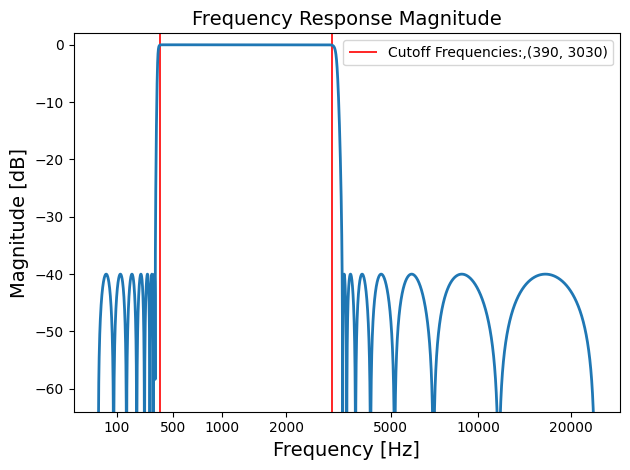

In [16]:
w, h = sg.freqz_sos(bp_sos, worN=np.linspace(0, BITRATE // 2, BITRATE // 2), fs=BITRATE)
w_mel = hz_to_mel(w)
h_dB = 20 * np.log10(np.abs(h))

# Magnitude visualization
figure = plt.figure()
ax = figure.add_subplot(1, 1, 1)
ax.set_title(r'Frequency Response Magnitude', fontsize=14)

ax.set_xlabel(r'Frequency [Hz]', fontsize=14)

# Manually set ticks at meaningful Hz values, converted to mel
tick_hz = [100, 500, 1000, 2000, 5000, 10000, 20000]
ax.set_xticks([hz_to_mel(f) for f in tick_hz])
ax.set_xticklabels([str(f) for f in tick_hz])

ax.set_ylabel(r'Magnitude [dB]', fontsize=14)
ax.set_ylim(-64, 2)

ax.vlines([hz_to_mel(fL), hz_to_mel(fH)], ymin=-64, ymax=2, color='red', lw=1.2, zorder=0, label=r'Cutoff Frequencies:,' f'{fL, fH}')

ax.plot(w_mel, h_dB, lw=2, zorder=1)

plt.legend()
plt.tight_layout()
plt.savefig('mag.png', dpi=150, bbox_inches='tight')
print("Saved mag.png")

Saved phase.png


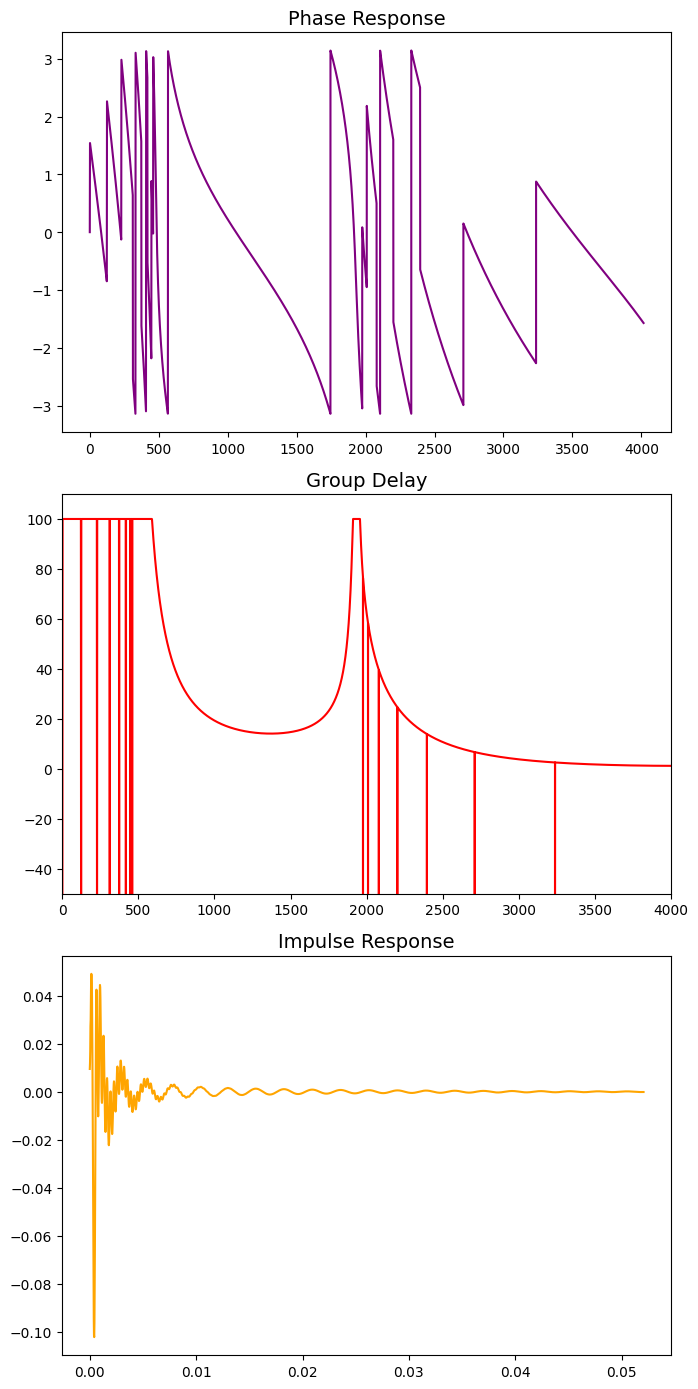

In [92]:
phase = np.angle(h)
phase_unwrapped = np.unwrap(phase)
dw = (np.pi) / len(phase_unwrapped)
gd_diff = -np.diff(phase_unwrapped) / dw
w_gd_mel = hz_to_mel(w[:-1])


gd_max = 100
for i in range(len(gd_diff)):
    if np.abs(gd_diff[i]) > gd_max:
        if gd_diff[i] > 0:
            gd_diff[i] = gd_max
        else:
            gd_diff[i] = -gd_max


impulse = np.zeros(2500)
impulse[0] = 1
ir = sg.sosfilt(bp_sos, impulse)
t = np.arange(2500) / BITRATE

# Phase, group delay, and impulse response visualization
figure = plt.figure(num=3, figsize=(FIGURE_WIDTH * 0.7, FIGURE_WIDTH * 0.7 * 2))
plt.subplots_adjust(hspace=5)
ax1 = figure.add_subplot(3, 1, 1)
ax1.set_title(r'Phase Response', fontsize=14)
ax1.plot(w_mel, phase, color='Purple')

ax2 = figure.add_subplot(3, 1, 2)
ax2.set_title(r'Group Delay', fontsize=14)
ax2.plot(w_mel[1:], gd_diff, color='Red')
ax2.set_ylim(-gd_max / 2, 1.1 * gd_max)
ax2.set_xlim(0, 4000)

ax2 = figure.add_subplot(3, 1, 3)
ax2.set_title(r'Impulse Response', fontsize=14)
ax2.plot(t, ir, color='Orange')

plt.tight_layout()
plt.savefig('phase.png', dpi=250, bbox_inches='tight')
print("Saved phase.png")